<a href="https://colab.research.google.com/github/alexis-chaesong/Vision-AI-Notebooks/blob/main/02_Deep-Dive-Datasets/Pure_Python_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 날것의 선형회귀 구현

import torch
import numpy as np

# a,b는 가중치, c는 편향
a = torch.randn(1, requires_grad=True)    # requires_grad는 c++ 엔진 레벨이기에 직접 구현 안함 / 어차피 파이토치의 자동미분
b = torch.randn(1, requires_grad=True)
c = torch.randn(1, requires_grad=True)

x_np = np.linspace(-1,1,100)  # arange(1,100,1) 대신 데이터 정규화를 통해 성능 개선
x = torch.tensor(x_np).float()

y_true = 2*(x**2) + 3*x + 1

for epoch in range(5000):
  # forward : 데이터(x)가 가중치(a,b,c)와 만나서 예측값(y_pred)가 되는 과정
  y_pred = a*(x**2) + b*x + c
  loss = torch.mean((y_pred - y_true)**2)   # 제곱으로 모든 오차 양수 / 큰 오차를 크게 징벌 / 미분의 편의성(깔끔한 일차식)

  with torch.no_grad():   # 미분 그래프에 기록 X

    # 학습률: 속도 조절기
    lr = 0.0001

    # grad의 의미: 손실함수(loss)를 해당 가중치(a)로 미분한 값

    # 크기: 성큼성큼, 살금살금? (기울기의 절댓값)
    # grad_a 기울기의 절댓값이 크면 현재 정답에서 아주 멀리 떨어져있고, 경사가 급함. 오차가 크니까 많이 수정하게 됨
    # 기울기의 절댓값이 작으면 경사가 완만, 오차가 작으니 살금살금

    # backward: 수동 미분 구현

    # 오차(error)가 크면, grad_a가 커지고 수정량(lr*grad_a)가 커짐(크기)
    # 오차가 플러스이면, grad_a가 플러스, a에서 그만큼을 뺌(방향), 마이너스면 반대

    error = y_pred - y_true
    grad_a = torch.mean(2*error*(x**2))  # 가중치가 전체 손실에 얼마나 기여했는지 계산
    grad_b = torch.mean(2*error*x)
    grad_c = torch.mean(2*error*1)

    # tensor([1.8240], requires_grad=True) tensor([1.1119], requires_grad=True) tensor([0.1513], requires_grad=True)
    # a,b,c의 변화 속도가 다른 것을 해결하기 위해 Adam과 같은 고급 최적화 함수를 사용

    # opimizer: 수동 가중치 업데이트
    # a = a - lr * grad
    # 새로운 가중치 = 이전 가중치 -(학습률*경사)
    # 방향: 더할까, 뺄까(기울기의 부호)
    a -= lr * grad_a
    b -= lr * grad_b
    c -= lr * grad_c

    # 원래는 초기화 필수 a.grad.zero_()    # 언더바는 새로운 변수를 만들지 말고, 현재 변수의 내용을 직접 수정

    # 자동 방식: loss.backward() 호출 -> 파이토치가 수식 계산 -> a.grad에 저장
    # 수동 방식 (현재): 수식 계산 -> grad_a 변수에 저장 -> 직접 가중치에서 뺌

  if epoch % 10 ==0:
    print(f'Epoch {epoch}: Loss {loss.item()}')
    print(a,b,c)


## 구조 정리
# 텐서로 바꾼 x, 입력값
# y_true 진짜 답
# for문 안에 먼저 forward: 예측값 y_pre와 손실 함수 loss 계산
# 학습률 설정
# backward: 미분하기
# optimizer: 가중치 업데이트
# a.grad.zero_(): 초기화 필수


Epoch 0: Loss 10.2235746383667
tensor([1.2161], requires_grad=True) tensor([0.3490], requires_grad=True) tensor([-1.5214], requires_grad=True)
Epoch 10: Loss 10.185128211975098
tensor([1.2181], requires_grad=True) tensor([0.3508], requires_grad=True) tensor([-1.5158], requires_grad=True)
Epoch 20: Loss 10.146841049194336
tensor([1.2201], requires_grad=True) tensor([0.3526], requires_grad=True) tensor([-1.5103], requires_grad=True)
Epoch 30: Loss 10.108718872070312
tensor([1.2222], requires_grad=True) tensor([0.3544], requires_grad=True) tensor([-1.5047], requires_grad=True)
Epoch 40: Loss 10.070756912231445
tensor([1.2242], requires_grad=True) tensor([0.3562], requires_grad=True) tensor([-1.4992], requires_grad=True)
Epoch 50: Loss 10.032955169677734
tensor([1.2262], requires_grad=True) tensor([0.3580], requires_grad=True) tensor([-1.4937], requires_grad=True)
Epoch 60: Loss 9.995312690734863
tensor([1.2282], requires_grad=True) tensor([0.3598], requires_grad=True) tensor([-1.4882], re

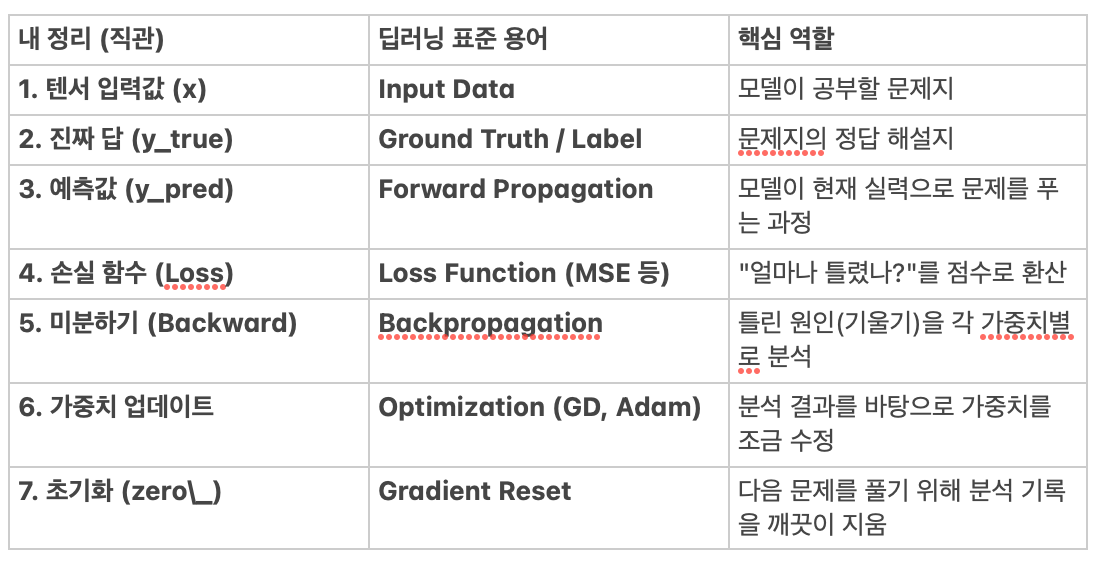